In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

states = pd.read_csv("../sources/state_competitiveness.csv")

states.head()

,State,Electricity_Price_cents_per_kWh,Grid_Capacity_MW,Renewable_Share_Percent,Carbon_Intensity_kgCO2_per_kWh,Power_Reliability_Score,Transmission_Congestion_Score,Land_Availability_Score,Water_Stress_Score,Existing_Data_Center_Ecosystem_Score,...,Available_Transmission_Capacity_MW,Substation_Availability_Score,Load_Growth_Pressure_Percent,Power_Delivery_Risk_Score,Natural_Gas_Price_USD_per_MMBtu,Solar_Resource_Score,Geothermal_Potential_Score,Nuclear_Capacity_MW,Behind_The_Meter_Potential_Score,Regional_Competitiveness_Score
0,Texas,9.79,168317,14.7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Virginia,10.62,29147,6.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,12.74,32877,7.1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,California,27.04,96773,34.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Nevada,11.47,16725,22.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(states.columns)

Index(['State', 'Electricity_Price_cents_per_kWh', 'Grid_Capacity_MW',
       'Renewable_Share_Percent', 'Carbon_Intensity_kgCO2_per_kWh',
       'Power_Reliability_Score', 'Transmission_Congestion_Score',
       'Land_Availability_Score', 'Water_Stress_Score',
       'Existing_Data_Center_Ecosystem_Score',
       'Interconnection_Queue_Time_Years',
       'Available_Transmission_Capacity_MW', 'Substation_Availability_Score',
       'Load_Growth_Pressure_Percent', 'Power_Delivery_Risk_Score',
       'Natural_Gas_Price_USD_per_MMBtu', 'Solar_Resource_Score',
       'Geothermal_Potential_Score', 'Nuclear_Capacity_MW',
       'Behind_The_Meter_Potential_Score', 'Regional_Competitiveness_Score'],
      dtype='object')


In [12]:
states["price_score"] = (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"]
) / (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"].min()
)

#using installed grid capacity for varaible

states["capacity_score"] = (
    states["Grid_Capacity_MW"]
    - states["Grid_Capacity_MW"].min()
) / (
    states["Grid_Capacity_MW"].max()
    - states["Grid_Capacity_MW"].min()
)

states["renewable_score"] = (
    states["Renewable_Share_Percent"]
    - states["Renewable_Share_Percent"].min()
) / (
    states["Renewable_Share_Percent"].max()
    - states["Renewable_Share_Percent"].min()
)

In [13]:
data_center_counts = {
    "Virginia": 609,
    "Texas": 467,
    "California": 287,
    "Georgia": 219,
    "Ohio": 210,
    "Arizona": 156,
    "Washington": 103,
    "North Carolina": 93,
    "Oregon": 125,
    "Nevada": 71,
    "Utah": 43,
    "Pennsylvania": 131,
    "Illinois": 228,
    "Indiana": 122,
    "Tennessee": 61
}

states["data_center_count"] = states["State"].map(data_center_counts)

states["ecosystem_score"] = (
    states["data_center_count"] - states["data_center_count"].min()
) / (
    states["data_center_count"].max() - states["data_center_count"].min()
)

In [14]:
states["competitiveness_score"] = (
    0.30 * states["price_score"]
    + 0.30 * states["capacity_score"]
    + 0.20 * states["renewable_score"]
    + 0.20 * (states["ecosystem_score"] / 100)
)

ranking = states.sort_values("competitiveness_score", ascending=False)

ranking[[
    "State",
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "competitiveness_score"
]]

,State,price_score,capacity_score,renewable_score,ecosystem_score,competitiveness_score
0,Texas,1.000000,1.000000,0.280353,0.749117,0.657569
8,Washington,0.980290,0.130967,1.000000,0.106007,0.533589
7,Oregon,0.923478,0.046919,0.900662,0.144876,0.471541
4,Nevada,0.902609,0.040800,0.448124,0.049470,0.372746
5,Georgia,0.906667,0.186465,0.083885,0.310954,0.345339
14,Illinois,0.859710,0.227803,0.090508,0.326855,0.345009
1,Virginia,0.951884,0.119400,0.099338,1.000000,0.343253
9,North Carolina,0.892174,0.164895,0.083885,0.088339,0.334074
10,Utah,0.989565,0.000000,0.150110,0.000000,0.326892
13,Pennsylvania,0.842319,0.244109,0.000000,0.155477,0.326239


In [15]:
states["competitiveness_score"] = (
    0.40 * states["price_score"]
    + 0.40 * states["capacity_score"]
    + 0.20 * states["renewable_score"]
)

ranking = states.sort_values("competitiveness_score", ascending=False)

ranking[[
    "State",
    "price_score",
    "capacity_score",
    "renewable_score",
    "competitiveness_score"
]]

,State,price_score,capacity_score,renewable_score,competitiveness_score
0,Texas,1.000000,1.000000,0.280353,0.856071
8,Washington,0.980290,0.130967,1.000000,0.644503
7,Oregon,0.923478,0.046919,0.900662,0.568291
4,Nevada,0.902609,0.040800,0.448124,0.466988
5,Georgia,0.906667,0.186465,0.083885,0.454030
14,Illinois,0.859710,0.227803,0.090508,0.453107
1,Virginia,0.951884,0.119400,0.099338,0.448381
9,North Carolina,0.892174,0.164895,0.083885,0.439605
13,Pennsylvania,0.842319,0.244109,0.000000,0.434571
10,Utah,0.989565,0.000000,0.150110,0.425848


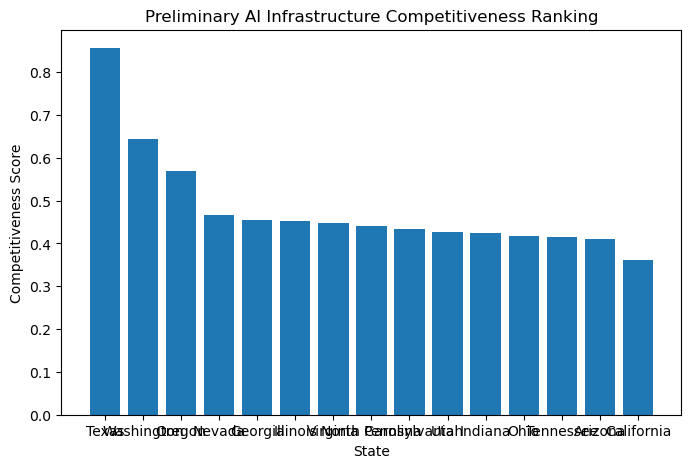

In [16]:
plt.figure(figsize=(8,5))
plt.bar(ranking["State"], ranking["competitiveness_score"])
plt.title("Preliminary AI Infrastructure Competitiveness Ranking")
plt.ylabel("Competitiveness Score")
plt.xlabel("State")
plt.show()

In [17]:
ecosystem_scores = {
    "Texas": 90,
    "Virginia": 100,
    "Arizona": 75,
    "California": 85
}

states["ecosystem_score"] = states["State"].map(ecosystem_scores)

In [18]:
ranking = states.sort_values(
    "competitiveness_score",
    ascending=False
)

ranking[[
    "State",
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "competitiveness_score"
]]

,State,price_score,capacity_score,renewable_score,ecosystem_score,competitiveness_score
0,Texas,1.000000,1.000000,0.280353,90.0,0.856071
8,Washington,0.980290,0.130967,1.000000,NaN,0.644503
7,Oregon,0.923478,0.046919,0.900662,NaN,0.568291
4,Nevada,0.902609,0.040800,0.448124,NaN,0.466988
5,Georgia,0.906667,0.186465,0.083885,NaN,0.454030
14,Illinois,0.859710,0.227803,0.090508,NaN,0.453107
1,Virginia,0.951884,0.119400,0.099338,100.0,0.448381
9,North Carolina,0.892174,0.164895,0.083885,NaN,0.439605
13,Pennsylvania,0.842319,0.244109,0.000000,NaN,0.434571
10,Utah,0.989565,0.000000,0.150110,NaN,0.425848


In [19]:
ranking[[
    "State",
    "Electricity_Price_cents_per_kWh",
    "Grid_Capacity_MW",
    "Renewable_Share_Percent",
    "ecosystem_score",
    "competitiveness_score"
]]

,State,Electricity_Price_cents_per_kWh,Grid_Capacity_MW,Renewable_Share_Percent,ecosystem_score,competitiveness_score
0,Texas,9.79,168317,14.7,90.0,0.856071
8,Washington,10.13,30975,47.3,NaN,0.644503
7,Oregon,11.11,17692,42.8,NaN,0.568291
4,Nevada,11.47,16725,22.3,NaN,0.466988
5,Georgia,11.40,39746,5.8,NaN,0.454030
14,Illinois,12.21,46279,6.1,NaN,0.453107
1,Virginia,10.62,29147,6.5,100.0,0.448381
9,North Carolina,11.65,36337,5.8,NaN,0.439605
13,Pennsylvania,12.51,48856,2.0,NaN,0.434571
10,Utah,9.97,10277,8.8,NaN,0.425848


In [20]:
gas_scores = {
    "Texas": 55.7,
    "Virginia": 54.5,
    "Arizona": 45.6,
    "California": 49.7
}

states["natural_gas_share"] = states["State"].map(gas_scores)

In [21]:
gas_scores = {
    "Texas": 55.7,
    "Virginia": 54.5,
    "Arizona": 45.6,
    "California": 49.7
}

states["natural_gas_share"] = states["State"].map(gas_scores)

states["btm_score"] = (
    states["natural_gas_share"] - states["natural_gas_share"].min()
) / (
    states["natural_gas_share"].max() - states["natural_gas_share"].min()
)

states[["State", "natural_gas_share", "btm_score"]]

,State,natural_gas_share,btm_score
0,Texas,55.7,1.000000
1,Virginia,54.5,0.881188
2,Arizona,45.6,0.000000
3,California,49.7,0.405941
4,Nevada,NaN,NaN
5,Georgia,NaN,NaN
6,Ohio,NaN,NaN
7,Oregon,NaN,NaN
8,Washington,NaN,NaN
9,North Carolina,NaN,NaN


In [22]:
states["competitiveness_score"] = (
    0.25 * states["price_score"]
    + 0.25 * states["capacity_score"]
    + 0.15 * states["renewable_score"]
    + 0.20 * (states["ecosystem_score"] / 100)
    + 0.15 * states["btm_score"]
)

ranking = states.sort_values("competitiveness_score", ascending=False)

ranking[[
    "State",
    "Electricity_Price_cents_per_kWh",
    "Grid_Capacity_MW",
    "Renewable_Share_Percent",
    "natural_gas_share",
    "ecosystem_score",
    "btm_score",
    "competitiveness_score"
]]

,State,Electricity_Price_cents_per_kWh,Grid_Capacity_MW,Renewable_Share_Percent,natural_gas_share,ecosystem_score,btm_score,competitiveness_score
0,Texas,9.79,168317,14.7,55.7,90.0,1.000000,0.872053
1,Virginia,10.62,29147,6.5,54.5,100.0,0.881188,0.614900
3,California,27.04,96773,34.0,49.7,85.0,0.405941,0.473677
2,Arizona,12.74,32877,7.1,45.6,75.0,0.000000,0.409884
4,Nevada,11.47,16725,22.3,NaN,NaN,NaN,NaN
5,Georgia,11.40,39746,5.8,NaN,NaN,NaN,NaN
6,Ohio,11.29,30491,2.3,NaN,NaN,NaN,NaN
7,Oregon,11.11,17692,42.8,NaN,NaN,NaN,NaN
8,Washington,10.13,30975,47.3,NaN,NaN,NaN,NaN
9,North Carolina,11.65,36337,5.8,NaN,NaN,NaN,NaN


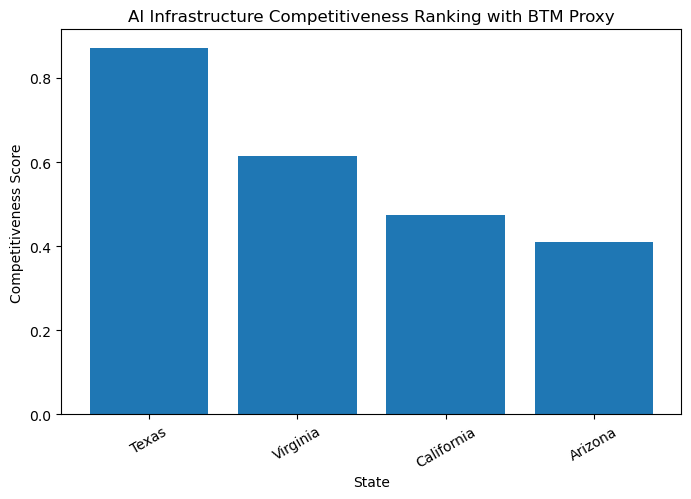

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking["State"],
    ranking["competitiveness_score"]
)

plt.title("AI Infrastructure Competitiveness Ranking with BTM Proxy")
plt.xlabel("State")
plt.ylabel("Competitiveness Score")
plt.xticks(rotation=30)
plt.show()

# Prelim Complete, adding more data moving forward

In [24]:
renewable_scores = {
    "Texas": 14.7,
    "Virginia": 6.5,
    "Arizona": 7.1,
    "California": 34.0,
    "Nevada": 22.3,
    "Georgia": 5.8,
    "Ohio": 2.3,
    "Oregon": 42.8,
    "Washington": 47.3,
    "North Carolina": 5.8,
    "Utah": 8.8,
    "Tennessee": 5.2,
    "Indiana": 6.0,
    "Pennsylvania": 2.0,
    "Illinois": 6.1
}

gas_scores = {
    "Texas": 55.7,
    "Virginia": 54.5,
    "Arizona": 45.6,
    "California": 49.7,
    "Nevada": 67.7,
    "Georgia": 35.5,
    "Ohio": 54.0,
    "Oregon": 57.1,
    "Washington": 26.1,
    "North Carolina": 39.0,
    "Utah": 31.6,
    "Tennessee": 17.5,
    "Indiana": 37.8,
    "Pennsylvania": 51.4,
    "Illinois": 13.3
}

In [25]:
data_center_counts = {
    "Virginia": 609,
    "Texas": 467,
    "California": 287,
    "Georgia": 219,
    "Ohio": 210,
    "Arizona": 156,
    "Washington": 103,
    "North Carolina": 93,
    "Oregon": 125,
    "Nevada": 71,
    "Utah": 43,
    "Pennsylvania": 131,
    "Illinois": 228,
    "Indiana": 122,
    "Tennessee": 61
}

states["data_center_count"] = states["State"].map(data_center_counts)

In [26]:
states["renewable_share"] = states["State"].map(renewable_scores)

states["natural_gas_share"] = states["State"].map(gas_scores)

states["btm_score"] = (
    states["natural_gas_share"]
    - states["natural_gas_share"].min()
) / (
    states["natural_gas_share"].max()
    - states["natural_gas_share"].min()
)

states["ecosystem_score"] = (
    states["data_center_count"]
    - states["data_center_count"].min()
) / (
    states["data_center_count"].max()
    - states["data_center_count"].min()
)

In [27]:
states["competitiveness_score"] = (
    0.20 * states["price_score"]
    + 0.20 * states["capacity_score"]
    + 0.15 * states["renewable_score"]
    + 0.20 * states["ecosystem_score"]
    + 0.25 * states["btm_score"]
)

In [28]:
ranking = states.sort_values(
    "competitiveness_score",
    ascending=False
)

ranking[[
    "State",
    "competitiveness_score",
    "data_center_count",
    "natural_gas_share",
    "renewable_share"
]]

,State,competitiveness_score,data_center_count,natural_gas_share,renewable_share
0,Texas,0.786729,467,55.7,14.7
1,Virginia,0.618496,609,54.5,6.5
7,Oregon,0.559441,125,57.1,42.8
4,Nevada,0.515794,71,67.7,22.3
3,California,0.468920,287,49.7,34.0
6,Ohio,0.455234,210,54.0,2.3
8,Washington,0.452276,103,26.1,47.3
13,Pennsylvania,0.423473,131,51.4,2.0
2,Arizona,0.399652,156,45.6,7.1
5,Georgia,0.395422,219,35.5,5.8


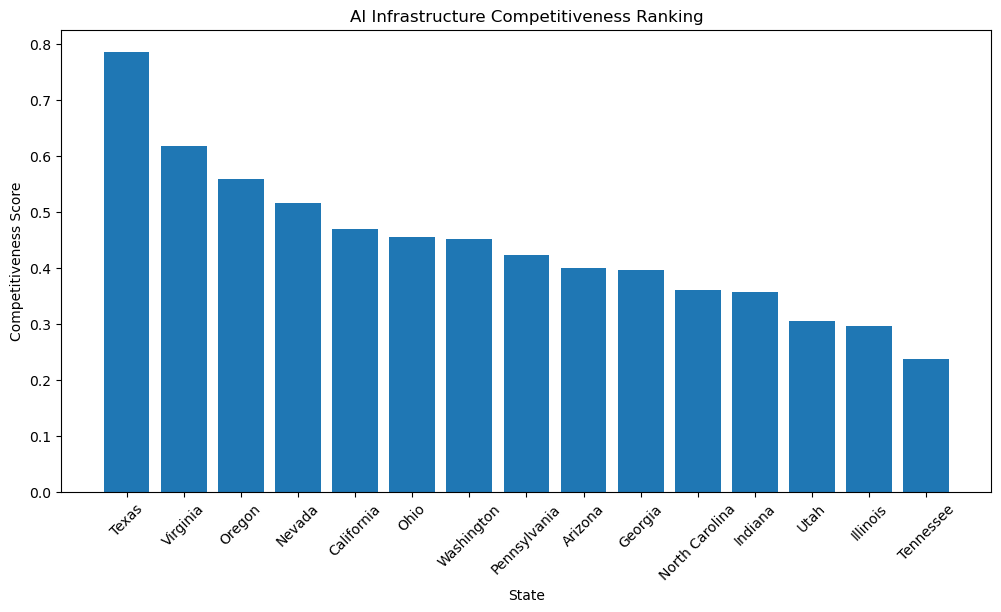

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    ranking["State"],
    ranking["competitiveness_score"]
)

plt.title(
    "AI Infrastructure Competitiveness Ranking"
)

plt.xlabel("State")
plt.ylabel("Competitiveness Score")

plt.xticks(rotation=45)

plt.show()

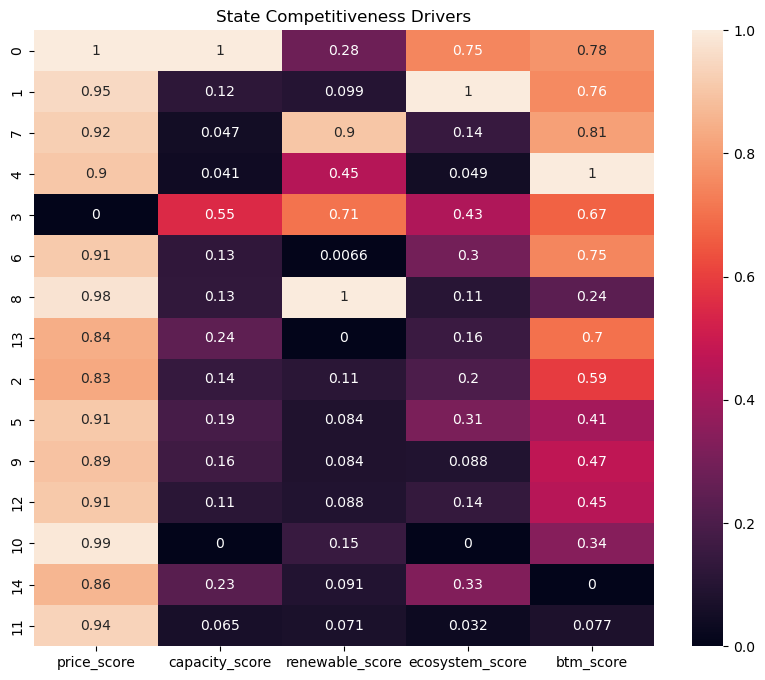

In [ ]:
import seaborn as sns

heatmap_data = ranking.set_index("State")[
    [
        "price_score",
        "capacity_score",
        "renewable_score",
        "ecosystem_score",
        "btm_score"
    ]
]

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_data,
    annot=True
)

plt.title(
    "State Competitiveness Drivers"
)

plt.show()